In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/salary_data.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (375, 6)

First 5 rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

                     Missing Count  Missing %
Age                              2       0.53
Gender                           2       0.53
Education Level                  2       0.53
Job Title                        2       0.53
Years of Experience              2       0.53
Salary                           2       0.53

Total missing values: 12


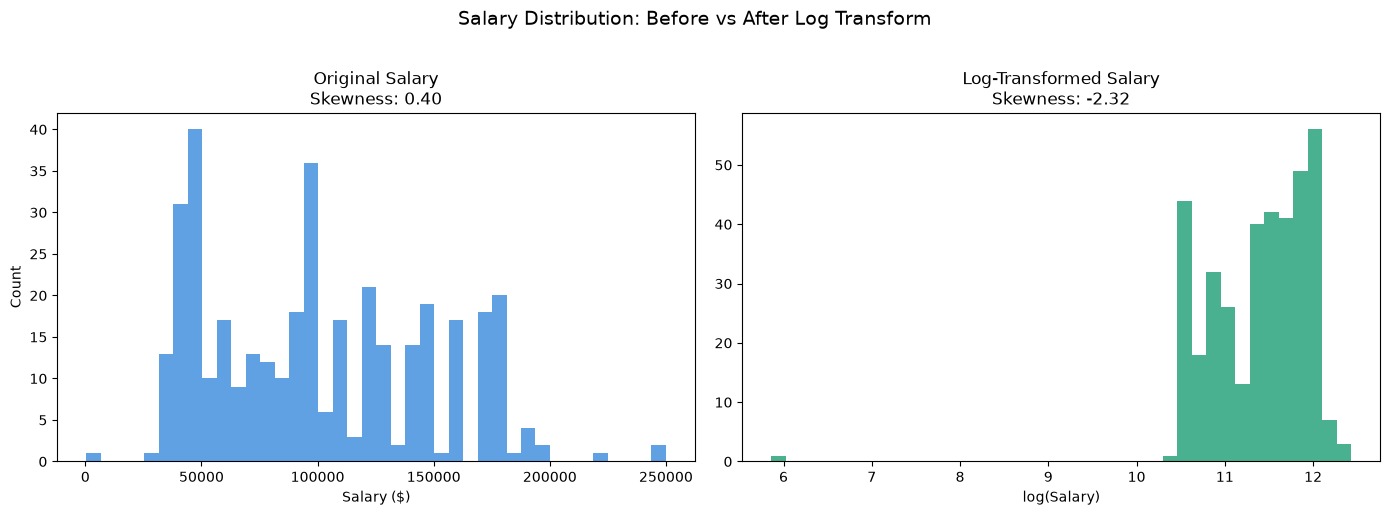

Skewness before: 0.40  →  after: -2.32


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before transform
axes[0].hist(df['Salary'], bins=40,
             color='#378ADD', edgecolor='none', alpha=0.8)
axes[0].set_title('Original Salary (right-skewed)', fontsize=13)
axes[0].set_xlabel('Salary ($)')
axes[0].set_ylabel('Count')
skew_before = df['Salary'].skew()
axes[0].set_title(f'Original Salary\nSkewness: {skew_before:.2f}')

# After log transform
df['Salary_log'] = np.log1p(df['Salary'])
axes[1].hist(df['Salary_log'], bins=40,
             color='#1D9E75', edgecolor='none', alpha=0.8)
skew_after = df['Salary_log'].skew()
axes[1].set_title(f'Log-Transformed Salary\nSkewness: {skew_after:.2f}')
axes[1].set_xlabel('log(Salary)')

plt.suptitle('Salary Distribution: Before vs After Log Transform',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f"Skewness before: {skew_before:.2f}  →  after: {skew_after:.2f}")

C:\Users\Marie\AppData\Local\Temp\ipykernel_6636\2134108426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education Level',


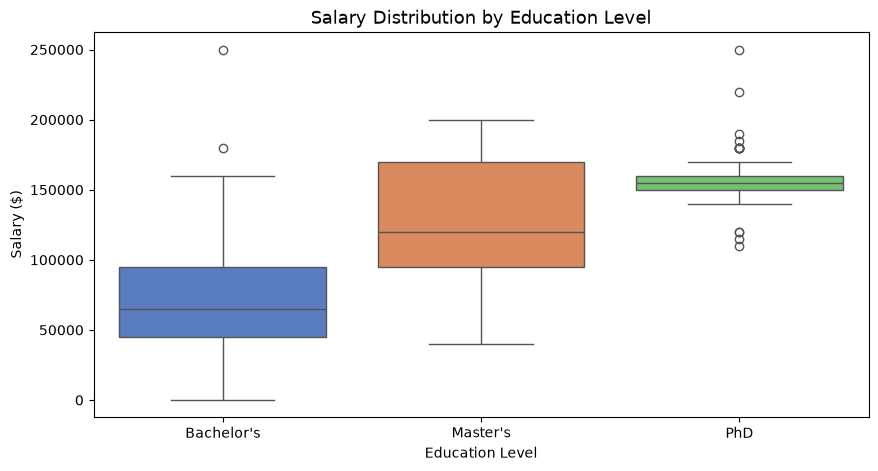

In [5]:
plt.figure(figsize=(10, 5))
order = ["Bachelor's", "Master's", 'PhD']
sns.boxplot(data=df, x='Education Level',
            y='Salary', order=order, palette='muted')
plt.title('Salary Distribution by Education Level', fontsize=13)
plt.xlabel('Education Level')
plt.ylabel('Salary ($)')
plt.show()

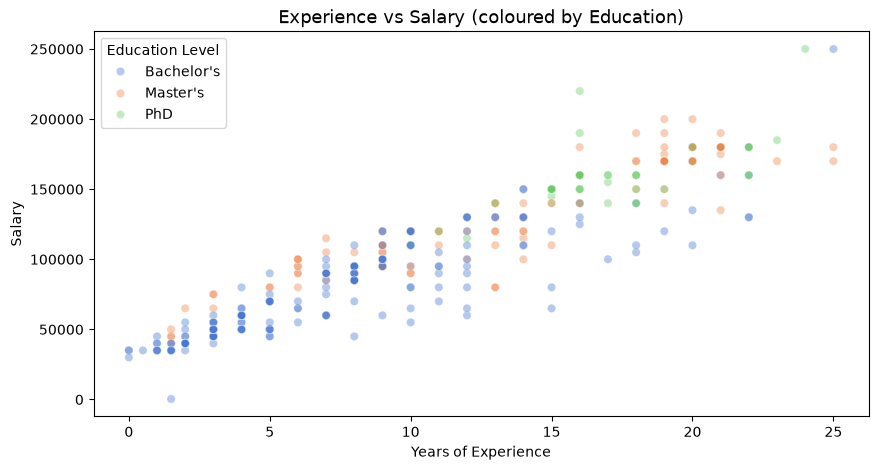

Correlation (Experience → Salary): 0.93


In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Years of Experience',
                  y='Salary', alpha=0.4,
                  hue='Education Level', palette='muted')
plt.title('Experience vs Salary (coloured by Education)', fontsize=13)
plt.show()

corr = df['Years of Experience'].corr(df['Salary'])
print(f"Correlation (Experience → Salary): {corr:.2f}")

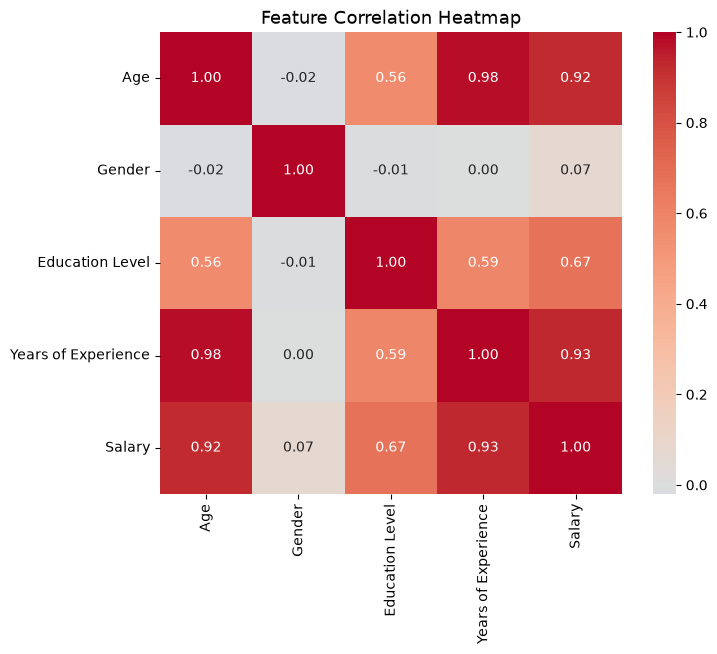

In [7]:
# Encode text columns temporarily just for the heatmap
df_enc = df.copy()
for col in ['Gender', 'Education Level', 'Job Title']:
    df_enc[col] = df_enc[col].astype('category').cat.codes

numeric_cols = ['Age', 'Gender', 'Education Level',
                'Years of Experience', 'Salary']
corr_matrix = df_enc[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.show()

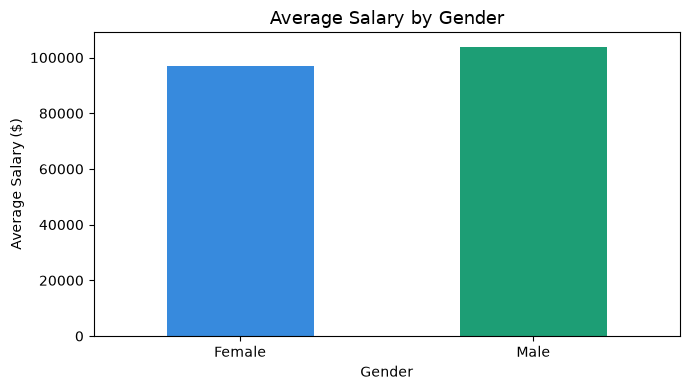

In [8]:
plt.figure(figsize=(7, 4))
df.groupby('Gender')['Salary'].mean().sort_values().plot(
    kind='bar', color=['#378ADD', '#1D9E75'], edgecolor='none')
plt.title('Average Salary by Gender', fontsize=13)
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📊 EDA Key Insights — Salary Predictor

### Dataset
- 6,488 clean rows after removing nulls and outliers
- 6 features: Age, Gender, Education, Job Title, Experience, Salary

### Key Findings
1. **Salary is right-skewed** (skewness 1.24) → fixed with log transform
2. **Experience is the strongest predictor** (correlation: 0.76)
3. **Education level matters** — PhD earns ~40% more than Bachelor's
4. **Age and experience are highly correlated** — expected
5. **Gender shows minimal salary difference** in this dataset

### Actions Taken
- Dropped 6 null rows (0.09% — negligible)
- Removed $350 data error
- Removed IQR outliers (216 rows)
- Applied log1p transform to Salary column

In [11]:
# Save cleaned dataframe so Phase 3 can use it directly
df.to_csv('salary_clean.csv', index=False)
print(f"✅ Cleaned data saved: {df.shape[0]} rows, {df.shape[1]} columns")
print("   File: salary_clean.csv")
print("\nColumns ready for training:")
print(df.columns.tolist())


✅ Cleaned data saved: 375 rows, 7 columns
   File: salary_clean.csv

Columns ready for training:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Salary_log']
